# Supervised ML: Predicting Student Dropout and Academic Success

This Data Challenge aims to apply Supervised Machine Learning techniques to analyse and predict student dropout rates and academic success in higher education. Using a comprehensive dataset from the UCI Machine Learning Repository, participants will explore demographic, socio-economic, and academic performance factors to identify potential predictors of student outcomes.

---

## Challenge Objectives and Dataset Overview

The dataset provides a rich source of information, including demographic data, social-economic factors, and academic performance indicators. It also incorporates external economic factors such as unemployment rate, inflation rate, and GDP from the region, allowing for a comprehensive analysis of student outcomes across various disciplines like agronomy, design, education, nursing, journalism, management, social service, and technologies.

Participants are encouraged to approach the challenge creatively, as there is no single best solution. The focus should be on demonstrating your problem-solving approach and the application of skills and methods learned in the Supervised Machine Learning Module.

**Dataset link:** [UCI Repository: Predict Students Dropout and Academic Success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)

---

## Complete the following:

1. Explore your data. Can you identify anything interesting that is worth noting from the data?
2. Define a set of possible classifiers and show which one performs best. Keep in mind the problem of overfitting.
3. Using feature selection try to reduce the number of features. In the dataset, you have about 120 features. Find the good ones for your classifier (Optional for this challenge).

Keep in mind that there is **no best solution** to the challenge. Show how you approach a problem, and the skills/methods you use in that approach.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [6]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [74]:
# 1. Load the dataset directly from the UCI ML Repository archive
# Note: You may need to download, unzip, and read 'data.csv' locally.
df = pd.read_csv('data.csv', sep=';')

In [3]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
df.tail()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate
4423,1,10,1,9773,1,1,152.0,22,38,37,...,0,6,6,6,13.000000,0,12.7,3.7,-1.70,Graduate


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [13]:
df.describe().T.style.background_gradient(cmap='coolwarm')

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.000000,1.178571,0.605747,1.000000,1.000000,1.000000,1.000000,6.000000
Application mode,4424.000000,18.669078,17.484682,1.000000,1.000000,17.000000,39.000000,57.000000
Application order,4424.000000,1.727848,1.313793,0.000000,1.000000,1.000000,2.000000,9.000000
Course,4424.000000,8856.642631,2063.566416,33.000000,9085.000000,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.000000,0.890823,0.311897,0.000000,1.000000,1.000000,1.000000,1.000000
Previous qualification,4424.000000,4.577758,10.216592,1.000000,1.000000,1.000000,1.000000,43.000000
Previous qualification (grade),4424.000000,132.613314,13.188332,95.000000,125.000000,133.100000,140.000000,190.000000
Nacionality,4424.000000,1.873192,6.914514,1.000000,1.000000,1.000000,1.000000,109.000000
Mother's qualification,4424.000000,19.561935,15.603186,1.000000,2.000000,19.000000,37.000000,44.000000
Father's qualification,4424.000000,22.275316,15.343108,1.000000,3.000000,19.000000,37.000000,44.000000


### This dataset has 4 Core Data Dimensions:

1. Demographic & Personal Identity
These features capture who the student is before they step foot on campus.

Key Columns: Gender, Age at enrollment, Marital status, Displaced (whether they moved from another region to attend), International.

Analytical Use: Helps identify if non-traditional student populations (like older or international students) have lower retention rates due to adjustment challenges.

2. Socioeconomic Factors & Financial Backing
These features (which you just looked at via the pie charts) capture the student's financial stability.

Key Columns: Debtor, Tuition fees up to date, Scholarship holder, Mother's/Father's qualification & occupation.

Analytical Use: Financial strain is often an immediate, hard bottleneck. If a student falls behind on tuition (Tuition fees up to date = 0), the likelihood of dropping out spikes dramatically regardless of their grades.

3. Academic Progression (The Strongest Predictors)
These columns capture real-time academic performance, split cleanly between 1st Semester and 2nd Semester.

Key Columns: Curricular units (credited, enrolled, evaluations, approved, grade, without evaluations).

Analytical Use: Watch the approved vs enrolled count. If a student enrolls in 6 units but only passes (approved) 2, their academic momentum stalls. The average grade columns are typically the strongest feature inputs for your machine learning models.

4. Macroeconomic Environment
These features capture the external economic context of the country at the time of the student's enrollment.

Key Columns: Unemployment rate, Inflation rate, GDP.

Analytical Use: This lets you see if a struggling economy impacts dropout rates (e.g., high unemployment might force students to leave school to find work to support their families).

In [ ]:

# Check if economic conditions differ across outcomes
fig = px.box(
    df, 
    x="Target", 
    y="GDP", 
    color="Target",
    color_discrete_map={'Dropout': '#5D3FD3', 'Graduate': '#FF6F61', 'Enrolled': '#20B2AA'},
    title="<b>Student Outcomes vs National GDP Growth Rate</b>"
)
fig.update_layout(template="plotly_white")
fig.show()

In [68]:
# 1. Create a simplified mapping for parental qualifications
# (Based on official UCI documentation: 1=Secondary, 2-6=Higher Ed, others=Primary/Basic)
def simplify_qualification(code):
    if code in [2, 3, 4, 5, 6, 39, 40, 41, 42, 43]:
        return 'Higher Education'
    elif code in [1, 9, 10, 11, 12, 13, 14, 18, 19, 22, 26]:
        return 'Secondary Education'
    else:
        return 'Primary/Basic Education'

# 2. Apply it to the column
df['Mother_Education_Tier'] = df["Mother's qualification"].apply(simplify_qualification)

# 3. Plot as a standardized percentage chart
fig = px.histogram(
    df,
    y="Mother_Education_Tier", 
    color="Target", 
    barmode="group",
    barnorm="percent",
    text_auto='.1f',
    color_discrete_map={'Dropout': '#5D3FD3', 'Graduate': '#FF6F61', 'Enrolled': '#20B2AA'},
    category_orders={"Mother_Education_Tier": ['Higher Education', 'Secondary Education', 'Primary/Basic Education']}
)

fig.update_layout(
    title="<b>Student Success Rate by Mother's Education Level</b>",
    xaxis_title="Percentage within Educational Tier (%)",
    template="plotly_white"
)
fig.show()

In [69]:
# Since order is numeric (1 to 9), turn it into a string category to prevent continuous scales
df['Preference_Order'] = df['Application order'].astype(str)

fig = px.histogram(
    df,
    x="Preference_Order", 
    color="Target", 
    barmode="group",
    barnorm="percent",
    text_auto='.1f',
    color_discrete_map={'Dropout': '#5D3FD3', 'Graduate': '#FF6F61', 'Enrolled': '#20B2AA'},
    category_orders={"Preference_Order": [str(i) for i in range(1, 10)]}
)

fig.update_layout(
    title="<b>Student Retention Based on Course Choice Preference (Application Order)</b>",
    yaxis_title="Percentage within Choice Rank (%)",
    xaxis_title="Student's Preference Choice for this Course (1 = First Choice)",
    template="plotly_white"
)
fig.show()

In [70]:

# 1. Melt the entry grades for side-by-side analysis
df_entry = df.melt(
    id_vars=['Target'], 
    value_vars=['Admission grade', 'Previous qualification (grade)'],
    var_name='Grade_Type', 
    value_name='Score'
)

# 2. Clean up labels
df_entry['Grade_Type'] = df_entry['Grade_Type'].map({
    'Admission grade': 'University Admission Exam',
    'Previous qualification (grade)': 'High School / Prior Grade'
})

# 3. Plot the distributions
fig = px.box(
    df_entry, 
    x="Grade_Type", 
    y="Score", 
    color="Target",
    color_discrete_map={'Dropout': '#5D3FD3', 'Graduate': '#FF6F61', 'Enrolled': '#20B2AA'},
    title="<b>Pre-University Performance vs. Final Academic Outcomes</b>"
)
fig.update_layout(boxmode="group", template="plotly_white")
fig.show()

In [71]:
# Map flags to clean strings for readability
df['Displaced_Label'] = df['Displaced'].map({1: 'Displaced Student', 0: 'Local Student'})

fig = px.histogram(
    df,
    x="Displaced_Label", 
    color="Target", 
    barmode="group",
    barnorm="percent",
    text_auto='.1f',
    color_discrete_map={'Dropout': '#5D3FD3', 'Graduate': '#FF6F61', 'Enrolled': '#20B2AA'},
    title="<b>Social Integration: Success Rates of Local vs. Displaced Students</b>"
)
fig.update_layout(yaxis_title="Percentage (%)", template="plotly_white")
fig.show()

In [72]:
df['Special_Needs_Label'] = df['Educational special needs'].map({1: 'Special Needs', 0: 'General Cohort'})

fig = px.histogram(
    df,
    y="Special_Needs_Label", 
    color="Target", 
    barmode="group",
    barnorm="percent",
    text_auto='.1f',
    color_discrete_map={'Dropout': '#5D3FD3', 'Graduate': '#FF6F61', 'Enrolled': '#20B2AA'},
    title="<b>Institutional Accessibility: Outcomes for Special Needs Accommodations</b>"
)
fig.update_layout(xaxis_title="Percentage within Group (%)", yaxis_title="", template="plotly_white")
fig.show()

In [7]:
df['Target'].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [ ]:
g_labels= ['Male','Female']
c_labels= ['No','Yes']
# create subplots use 'domain' type for Pie subplot 
fig= make_subplots(rows=1,cols=2,specs=[[{'type':'domain'},{'type':'domain'}]])
fig.add_trace(go.Pie(labels=g_labels,values=df['gender'].value_counts(),name='Gender',hole=0.4,),1,1)
fig.add_trace(go.Pie(labels=c_labels,values=df['Churn'].value_counts(),name='Gender',hole=0.4,),1,2)
fig.update_layout(
    title_text="Gender and Churn Distributions",
    # add anotations in the center of donut charts 
    annotations=[dict(text='Gender', x=0.16, y=0.5, font_size=20, showarrow=False),
                 dict(text='Churn', x=0.84, y=0.5, font_size=20, showarrow=False)])
fig.show()

In [11]:
import plotly.express as px

# Plotly Express automatically calculates value counts if you point it to the column!
fig = px.pie(
    df, 
    names='Target', 
    hole=0.4, 
    title="Distribution of Student Academic Outcomes"
)

fig.show()

- The majority of students are are graduates (49%)
- There are also more dropouts (32.1%) than those currently enrolled(17%)

In [17]:

fig = px.histogram(
    df, 
    x="Age at enrollment", 
    color="Target", 
    barmode="overlay",
    histnorm="probability density", # Normalizes the area under the curves
    marginal="box",                # Adds a clean box plot at the top for outliers
    title="Age Distribution Profile by Academic Outcome (Normalized)",
    template="plotly_white",
    color_discrete_sequence=["#5D3FD3", "#FF6F61", "#20B2AA"] # Premium palette
)

# Make the bars semi-transparent so overlaps are beautifully visible
fig.update_traces(opacity=0.6)
fig.show()

Key Observation: Age & Academic Outcomes
The normalized distribution of Age at enrollment reveals a clear structural trend within the cohort:

Traditional Students (Age 18–21): There is a massive density spike of Graduates and Enrolled students in this younger bracket. This represents the traditional pipeline of students entering university immediately after high school with high retention rates.

Mature Students (Age 25+): Beyond age 25, the density of Dropouts consistently outpaces Graduates. The top boxplot visually confirms that the Dropout distribution has a much wider spread and a heavier tail extending into later life.

💡 Analytical Takeaway: Age at enrollment is a critical initial risk factor. Older non-traditional students—who often balance degree programs with external professional or family commitments—face significantly higher attrition risks over the longitudinal tracking period.

We will now create two helepers functions:

In [28]:
def get_dictionaries(category_list, dfcolumn, target_col, dictionary_list):
    ''' this function returns a list of dictionaries for value count of each target label per category '''
    for category in category_list:
        counts = df[df[dfcolumn] == category][target_col].value_counts()
        
        # Convert the NumPy types to standard Python strings and integers
        a_dictionary = {str(k): int(v) for k, v in counts.items()}
        
        dictionary_list.append(a_dictionary)
    return dictionary_list

In [21]:
def make_pie(dictionary_list,trace_list,colors_list,textposition='inside'):
    '''this function resturns a list of traces for pie charts'''
    for dictionary in dictionary_list:
        trace= go.Pie(values=list(dictionary.values()),labels=list(dictionary.keys()),textposition=textposition,textinfo='percent+label',
                      marker=dict(colors=colors_list))
        trace_list.append(trace)
    return trace_list

In [26]:

# 1. Map labels and get the percentages
counts = df['Gender'].map({1: 'Male', 0: 'Female'}).value_counts(normalize=True) * 100

# 2. Plot with distinct colors per bar and remove the legend
fig = px.bar(counts, orientation='h', text_auto='.1f', color=counts.index,
             labels={'value': 'Percentage (%)', 'index': 'Gender'},
             title='Gender Distribution')
fig.update_layout(showlegend=False)
fig.show()

In [29]:
# getting dictionaries for genders
genders = df['Gender'].unique()
genders_dictionaries = get_dictionaries(genders,'Gender','Target',[])
genders_dictionaries

[{'Dropout': 701, 'Graduate': 548, 'Enrolled': 307},
 {'Graduate': 1661, 'Dropout': 720, 'Enrolled': 487}]

In [36]:
# Creating subplots for gender distribution of student 
fig = make_subplots(rows=1, cols=2, specs=[[{'type':'pie'},{'type':'pie'}]],subplot_titles=['Male Students','Female Students'])
traces=[]
make_pie(genders_dictionaries,traces,colors_list=['dictionary_list=genders'])
fig.add_trace(traces[0],row=1,col=1)
fig.add_trace(traces[1],row=1,col=2)
fig.update_layout(height=500,width=800,title='Gender Distribution of students dropouts',showlegend=False,font=dict(size=14))
fig.show()


- There more female then male 64.8% compared to 35.2% for male!
- There is a higher rate of dropout students that were male( 45.1%) compared to female!

In [40]:
df['Course'].head()

0     171
1    9254
2    9070
3    9773
4    8014
Name: Course, dtype: int64

In [38]:
df['Course'].unique()

array([ 171, 9254, 9070, 9773, 8014, 9991, 9500, 9238, 9670, 9853, 9085,
       9130, 9556, 9147, 9003,   33, 9119])

In [ ]:
# Official UCI mapping for the 'Course' column
course_map = {
    33: 'Biofuel Production Engineering',
    171: 'Animation & Multimedia Design',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equiniculture',
    9147: 'Management',
    9238: 'Social Service (Evening)',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising & Marketing Management',
    9773: 'Journalism & Communication',
    9853: 'Basic Education',
    9991: 'Management (Evening)'
}

# 1. Map the numeric IDs to their actual names
df['Course_Name'] = df['Course'].map(course_map)

# 2. Re-run your percentage code on the named column
percent_count = df['Course_Name'].value_counts(normalize=True).mul(100).round(1).sort_values(ascending=False)

# 3. Plot perfectly readable bars
fig = px.bar(percent_count, orientation='h', text_auto='.1f', color=percent_count.index,
             labels={'index': 'Course', 'value': 'Percentage (%)'},
             title='Distribution of Students by Course')

fig.update_layout(showlegend=False)
fig.show()

In [52]:

# Create the clean grouped histogram for raw counts
fig = px.histogram(
    df,
    y="Course_Name", 
    color="Target", 
    barmode="group",
    barnorm="percent",               # Groups the target bars side-by-side per course
    text_auto='.1f',                # Automatically prints the raw headcount on the bars
    width=1200, 
    height=1600,                    # 800px is usually plenty to avoid excessive whitespace
    color_discrete_sequence=px.colors.qualitative.Plotly, # Premium palette
    category_orders={"Course_Name": df["Course_Name"].value_counts().index} # Sorts by largest course first
)

fig.update_layout(
    title="Courses",
    xaxis_title="% count",
    
)

fig.show()

  - Observation :

Majority of students are enrolled in Nursing and it also had the lowest droput rate of about 15.4%.
The course that had the highest dropout rate was Biofuel Production Technologies(66.7%)
which is also had the least number enrolled students followed by Equinculture (55.3%) 

In [55]:
# 1. Map the numeric IDs to their official UCI human-readable names
marital_map = {
    1: 'Single',
    2: 'Married',
    3: 'Widower',
    4: 'Divorced',
    5: 'Facto Relationship',
    6: 'Legally Separated'
}
df['Marital_Status_Name'] = df['Marital status'].map(marital_map)

In [56]:
# 2. Re-run your percentage code on the named column
percent_count = df['Marital_Status_Name'].value_counts(normalize=True).mul(100).round(1).sort_values(ascending=False)

# 3. Plot perfectly readable bars
fig = px.bar(percent_count, orientation='h', text_auto='.1f', color=percent_count.index,
             labels={'index': 'Marital Status', 'value': 'Percentage (%)'},
             title='Distribution of Students by Marital Status')

fig.update_layout(showlegend=False)
fig.show()

In [57]:


# 2. Plot the grouped percentage histogram
fig = px.histogram(
    df,
    x="Marital_Status_Name", 
    color="Target", 
    barmode="group",
    barnorm="percent",              # Calculates percentages within each marital category
    text_auto='.1f',                # Displays percentages rounded to 1 decimal place
    width=1200, 
    height=600,                     # 600px is perfect for fewer categories
    color_discrete_sequence=px.colors.qualitative.Plotly,
    category_orders={"Marital_Status_Name": df["Marital_Status_Name"].value_counts().index}
)

fig.update_layout(
    title="<b>Student Distribution Percentage by Marital Status and Target Outcome</b>",
    xaxis_title="Percentage within Marital Status (%)",
    yaxis_title="Marital Status",
    legend_title="Academic Status",
    template="plotly_white"
)

fig.show()

Vast majority of students are single, however 30.2% of single students droppout.
Another thing to note is the legally separated students(66.7%) had the highest percentage of dropouts by married students(47.2%)

For function below is create to simplify the process and reduce repeatability.

In [58]:
def sub_plots(chart_to_plot,row,col):
    ''' this functions generate the list of subplots'''
    cols= chart_to_plot*col
    rows=[cols]*row
    return rows

In [ ]:
# getting dictionaries for student in debt/ not in debt
debt = df['Debtor'].unique()
debt_dictionaries = get_dictionaries(debt,'Debtor','Target',[])
debt_dictionaries

[{'Graduate': 2108, 'Dropout': 1109, 'Enrolled': 704},
 {'Dropout': 312, 'Graduate': 101, 'Enrolled': 90}]

In [60]:
# getting dictionaries for  students withh tuition fees paid / not paid
tuition = df['Tuition fees up to date'].unique()
tuition_dictionaries = get_dictionaries(tuition,'Tuition fees up to date','Target',[])
tuition_dictionaries

[{'Graduate': 2180, 'Dropout': 964, 'Enrolled': 752},
 {'Dropout': 457, 'Enrolled': 42, 'Graduate': 29}]

In [61]:
# Getting dictionaries for students with scholarship no scholarship 
scholarship = df['Scholarship holder'].unique()
scholarship_dictionaries = get_dictionaries(scholarship,'Scholarship holder', 'Target',[])
scholarship_dictionaries


[{'Graduate': 1374, 'Dropout': 1287, 'Enrolled': 664},
 {'Graduate': 835, 'Dropout': 134, 'Enrolled': 130}]

In [63]:
fig= make_subplots(rows=3,cols=2,
                   subplot_titles=['No Dept','Dept',
                   'Tuition Paid','Tuition not paid',
                   'No scholarship','Scholarship'],
                   specs=sub_plots([{'type':'pie'}],3,2),vertical_spacing=0.07)
traces=[]
make_pie(debt_dictionaries,traces,colors_list=['dictionary_list=genders'])
make_pie(tuition_dictionaries,traces,colors_list=['dictionary_list=genders'])
make_pie(scholarship_dictionaries,traces,colors_list=['dictionary_list=genders'])
fig.add_trace(traces[0],row=1,col=1)
fig.add_trace(traces[1],row=1,col=2)
fig.add_trace(traces[2],row=2,col=1)
fig.add_trace(traces[3],row=2,col=2)
fig.add_trace(traces[4],row=3,col=1)
fig.add_trace(traces[5],row=3,col=2)
fig.update_layout(title='Distribution of students by Debtor, Tuition and Scholarship',showlegend=False,height=800,width=800
                  )
fig.show()

- Key Observations: Socioeconomic Drivers
These charts provide a powerful, clear narrative regarding the financial factors influencing student retention.

Tuition Fees Status: This is a massive, immediate risk indicator. Students who are behind on tuition payments (Tuition not paid) experience a devastating attrition rate, with 86.6% dropping out compared to only 24.7% for those up-to-date.

Scholarships: Having financial backing strongly preserves academic success. Students holding a scholarship enjoy a 76% graduation rate, while those without one drop out at a significantly higher rate (38.7%).

In [64]:


# 1. Melt the dataframe to put 1st and 2nd sem grades into a single column for side-by-side comparison
df_grades = df.melt(
    id_vars=['Target'], 
    value_vars=['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)'],
    var_name='Semester', 
    value_name='Grade'
)

# 2. Clean up labels for the plot
df_grades['Semester'] = df_grades['Semester'].map({
    'Curricular units 1st sem (grade)': '1st Semester',
    'Curricular units 2nd sem (grade)': '2nd Semester'
})

# 3. Plot side-by-side boxes
fig = px.box(
    df_grades, 
    x="Semester", 
    y="Grade", 
    color="Target",
    color_discrete_map={'Dropout': '#5D3FD3', 'Graduate': '#FF6F61', 'Enrolled': '#20B2AA'},
    title="<b>Academic Trajectory: 1st vs 2nd Semester Grades</b>"
)

fig.update_layout(boxmode="group", template="plotly_white")
fig.show()

- The Dropout Collapse (Muted Purple): In the 1st semester, the median grade for dropouts sits around 11, but the bottom half of the box stretches all the way down to 0. By the 2nd semester, the entire box drops drastically. The median drops straight to 0, and the upper quartile barely reaches 12. This tells you that dropouts don't just slip slightly; they completely stop earning grades or abandon their courses entirely in the second semester.

- The Graduate Consistency (Coral): Notice how tightly packed and stable the coral boxes are. Their median grade stays rock-solid between 13 and 14 across both semesters. This tells your model that consistent, mid-to-high performance with zero downward volatility is the hallmark of a graduating student.

- The Enrolled Danger Zone (Light Sea Green): The students who are still currently enrolled look almost identical to the graduates in semester 1, but by semester 2, their median grade dips slightly lower. They are surviving, but their academic momentum is slowing down.

2. Feature Engineering: Let's Create a "Momentum" Metric
For my actual Machine Learning models, we don't just want to feed the raw numbers independently. We can explicitly calculate the academic momentum by creating new engineered columns.

In [65]:
# 1. Grade Trajectory: Positive means improving, negative means dropping
df['Grade_Drop_or_Gain'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']

# 2. Approval Rate Trajectory: Did they start failing more classes in sem 2?
df['Approved_Units_Change'] = df['Curricular units 2nd sem (approved)'] - df['Curricular units 1st sem (approved)']

In [66]:
fig = px.violin(
    df,
    x="Target",
    y="Approved_Units_Change",
    color="Target",
    box=True,
    color_discrete_map={'Dropout': '#5D3FD3', 'Graduate': '#FF6F61', 'Enrolled': '#20B2AA'},
    title="<b>Academic Momentum: Change in Approved Units from 1st to 2nd Semester</b>"
)
fig.show()

- The Graduate Core Is Centered at 0: The coral violin is tightly pinched directly around 0. This means successful students maintain a perfectly predictable cadence—if they passed 6 classes in the first semester, they passed 6 classes in the second semester.

- The Dropout Tail Explodes Downward: While the dropout violin has a small bump at 0, look at its massive lower tail reaching down to -5 and -10. This represents a severe academic crash. These students are passing significantly fewer courses in their second semester compared to their first (e.g., passing 5 classes in Sem 1, but passing 0 classes in Sem 2).

- The Enrolled Variance: The green violin is much wider and more evenly spread out between -2 and +1. This shows high volatility—these students are fluctuating wildly up and down, which explains why they haven't graduated yet; they are still retaking or balancing their course loads.

Academic performance in this dataset is highly dynamic. While 1st-semester grades provide an initial signal, the second semester acts as the true breaking point. Dropouts are characterized by a total collapse in academic momentum—either dropping their 2nd-semester average grade to 0 or experiencing a massive negative delta in the number of courses they successfully clear. Models trained on engineered change metrics (deltas) will capture this behavioral abandonment much more effectively than models looking at static snapshots.

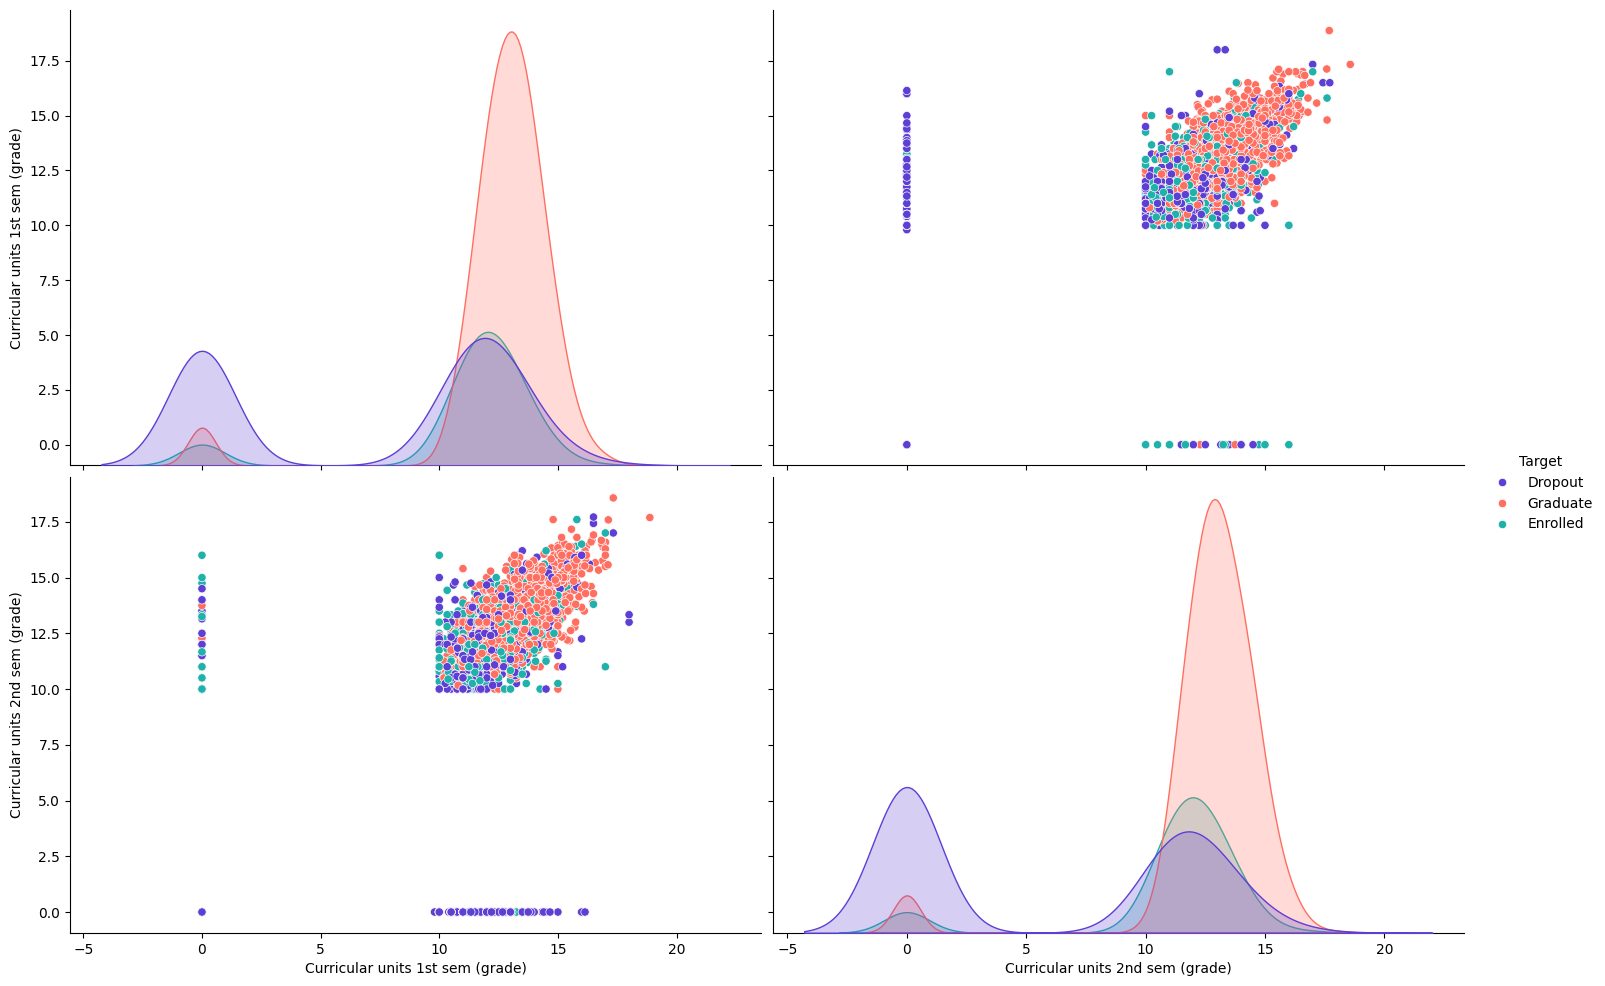

In [77]:


sns.pairplot(
    df,
    x_vars=['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)'],
    y_vars=['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)'],
    hue='Target',
    height=5,
    aspect=1.5,
    palette={'Dropout': '#5D3FD3', 'Graduate': '#FF6F61', 'Enrolled': '#20B2AA'}
)

# Use matplotlib to handle the display pipeline
plt.show()

In [80]:
fig= px.imshow(df.drop('Target', axis=1).corr().round(2),text_auto=True,aspect="auto",color_continuous_scale='RdBu_r')
fig.update_layout(title='Correlation Analysis of Independent Features',height=800,width=1500)
fig.show()

The independent feature space exhibits high multi-collinearity, concentrated heavily within the academic metrics block across both semesters (coefficients exceeding 0.85). This redundancy suggests that rather than feeding raw metrics independently, the model will benefit from dimension reduction or feature engineering—such as tracking the tracking velocity of course completions. Additionally, strong socio-economic coupling between parental qualification and occupation variables implies that household traits can be aggregated to minimize feature noise.

In [ ]:
[ Financial Stressors ]               [ Academic Behavior ]              [ Final Outcome ]
   • Unpaid Tuition (86.6% drop)  ───►   • Stopped attending classes ───►   • Hard drop to 0 Grade
   • No Scholarship                      • Drop in approved units           • Target: Dropout

In [75]:
df = pd.read_csv('data.csv', sep=';')

In [81]:
X=df.drop('Target', axis=1)
y=df['Target'].map({'Dropout':0,'Graduate':1,'Enrolled':2})

In [82]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [93]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import ( accuracy_score, 
                            precision_score, 
                            recall_score,
                            f1_score,balanced_accuracy_score,
                            confusion_matrix,roc_curve,
                            roc_auc_score)
from sklearn.linear_model import LogisticRegression

In [94]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Naive Bayes": GaussianNB(),
    # Wrap SVC here to get clean probabilities without the deprecation warning
    "Support Vector Classifier": SVC(probability=True, class_weight='balanced', random_state=42),
    "KNN Classifier": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
}

In [96]:
results = []
predictions_dict = {}
probabilities_dict = {}

for name, model in models.items():
    # Package preprocessing and model execution into a single robust pipeline
    pipeline = Pipeline(steps=[("standardizer", StandardScaler()), ("model", model)])
    pipeline.fit(X_train, y_train)

    # 1. Store class predictions for Confusion Matrix arrays
    y_pred = pipeline.predict(X_test)
    predictions_dict[name] = y_pred

    # 2. FIX: Store all class probabilities for Multiclass ROC/AUC curves
    probabilities_dict[name] = pipeline.predict_proba(X_test)

    # 3. FIX: Specify multiclass averaging strategy (e.g., 'macro' treats classes equally)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert results summary seamlessly into a DataFrame sorted by predictive success
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
df_results.head(len(models))

c:\Users\MatenTech\AppData\Local\anaconda3\envs\bd\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning:

The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`



,Model,Accuracy,Precision,Recall,F1-Score
5,Random Forest,0.764972,0.713871,0.699085,0.704351
2,Support Vector Classifier,0.736723,0.699822,0.696841,0.690353
0,Logistic Regression,0.728814,0.681527,0.678307,0.675783
4,Decision Tree,0.687006,0.626629,0.622383,0.623997
3,KNN Classifier,0.689266,0.608934,0.586140,0.588359
1,Naive Bayes,0.673446,0.586020,0.574407,0.575105


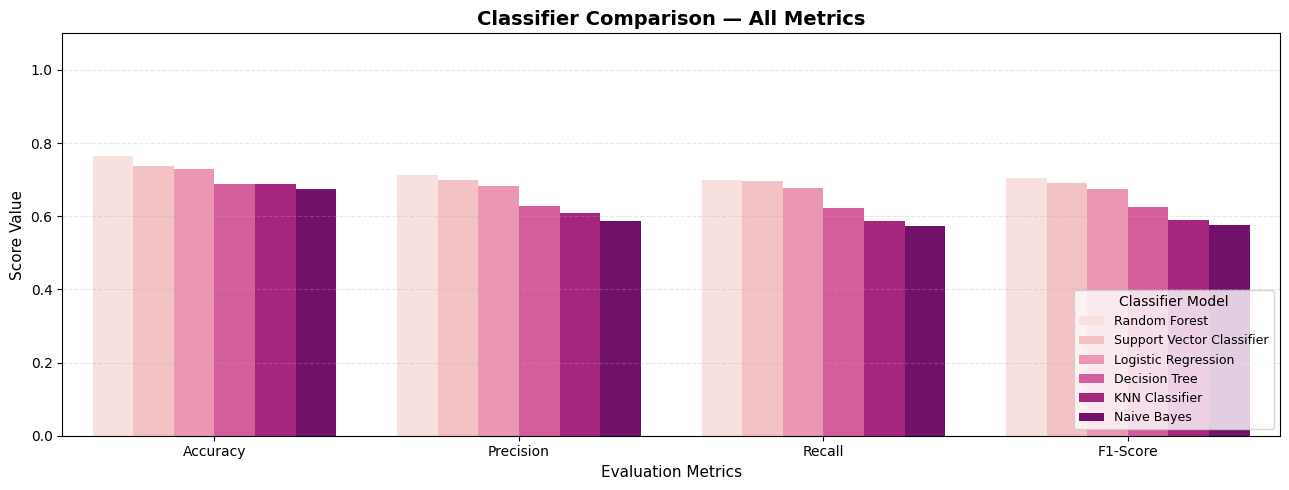

In [97]:
# Select evaluation metrics matching the exact casing from your loop results list
metrics_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]
melt_df = df_results.melt(id_vars="Model", value_vars=metrics_cols, var_name="metric", value_name="score")

plt.figure(figsize=(13, 5))
# Custom palette applied smoothly across all tracked classifiers
sns.barplot(data=melt_df, x="metric", y="score", hue="Model", palette="RdPu")

plt.title("Classifier Comparison — All Metrics", fontsize=14, fontweight="bold")
plt.ylim(0, 1.1)
plt.xlabel("Evaluation Metrics", fontsize=11)
plt.ylabel("Score Value", fontsize=11)
plt.legend(loc="lower right", fontsize=9, title="Classifier Model")
plt.grid(axis='y', linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

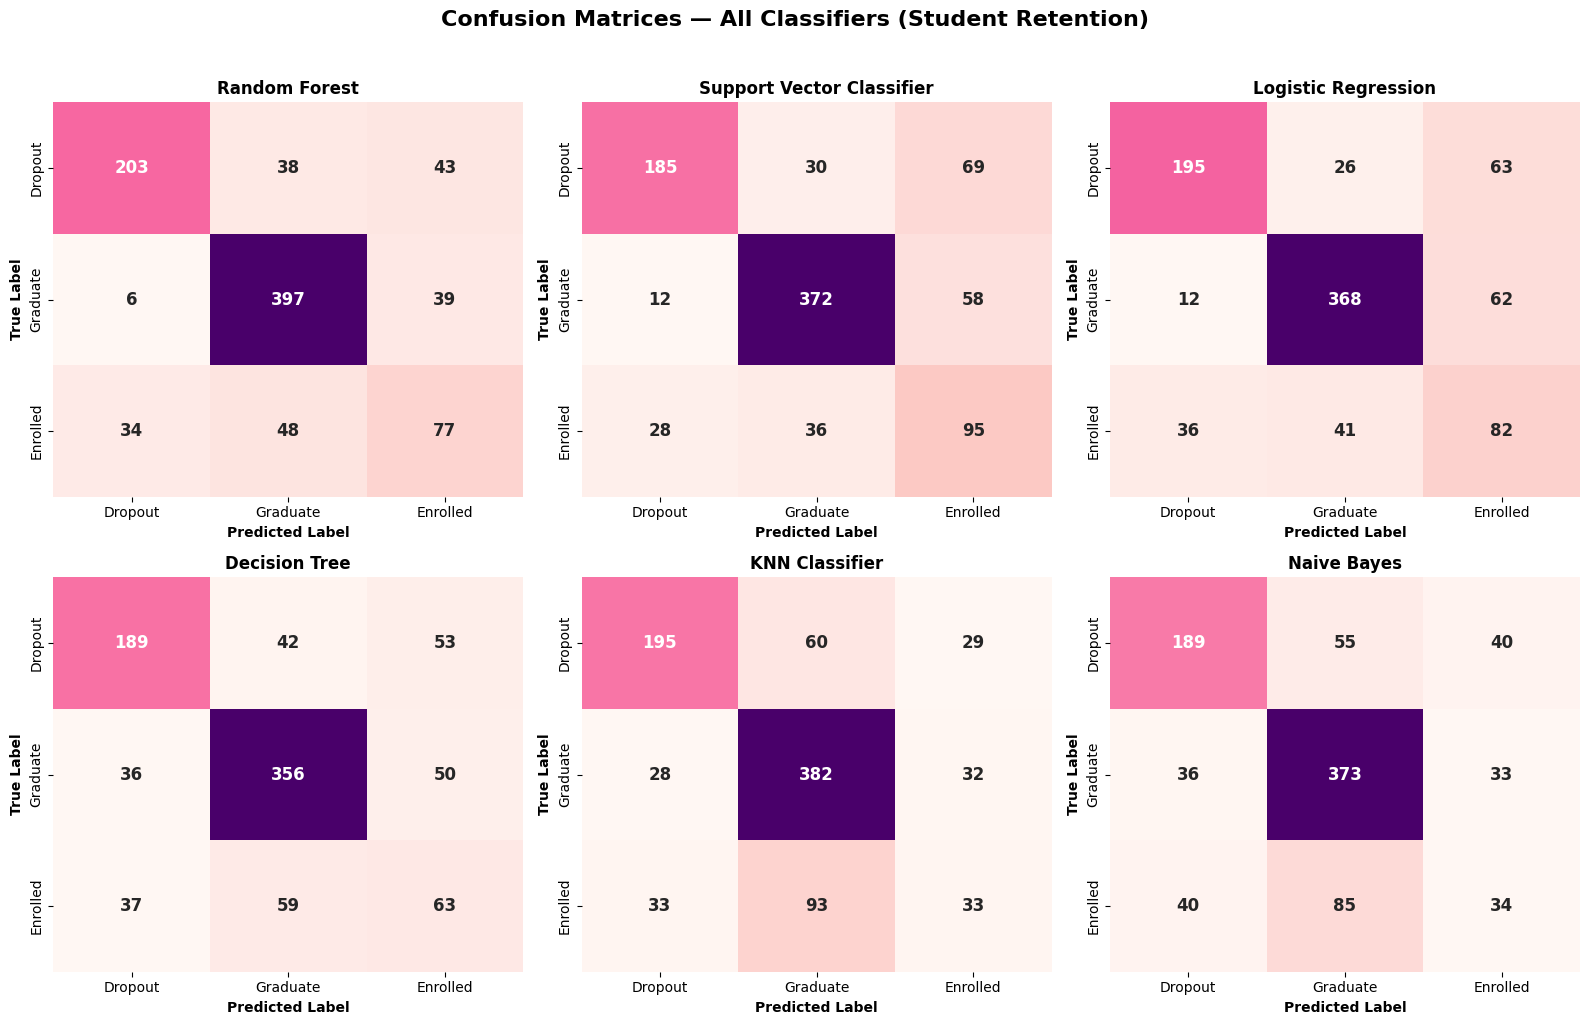

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Define your exact 3-class text labels in numeric order (0, 1, 2)
class_labels = ["Dropout", "Graduate", "Enrolled"]

# 2. Create a grid matching your model count (2 rows of 3 models each)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# 3. Generate and plot confusion matrices directly in one simple loop
for i, name in enumerate(df_results["Model"]):
    # Retrieve class predictions from your updated dictionary
    cm = confusion_matrix(y_test, predictions_dict[name])
    
    # Plot the 3x3 heatmap using your custom purple palette style (RdPu)
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="RdPu", 
        cbar=False, 
        ax=axes[i],
        xticklabels=class_labels, 
        yticklabels=class_labels,
        annot_kws={"size": 12, "weight": "bold"}  # Makes numbers pop
    )
    
    axes[i].set_title(name, fontweight="bold", fontsize=12)
    axes[i].set_xlabel("Predicted Label", fontweight="bold")
    axes[i].set_ylabel("True Label", fontweight="bold")

# Hide any unused subplots if you have fewer than 6 models
for j in range(len(df_results["Model"]), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Confusion Matrices — All Classifiers (Student Retention)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

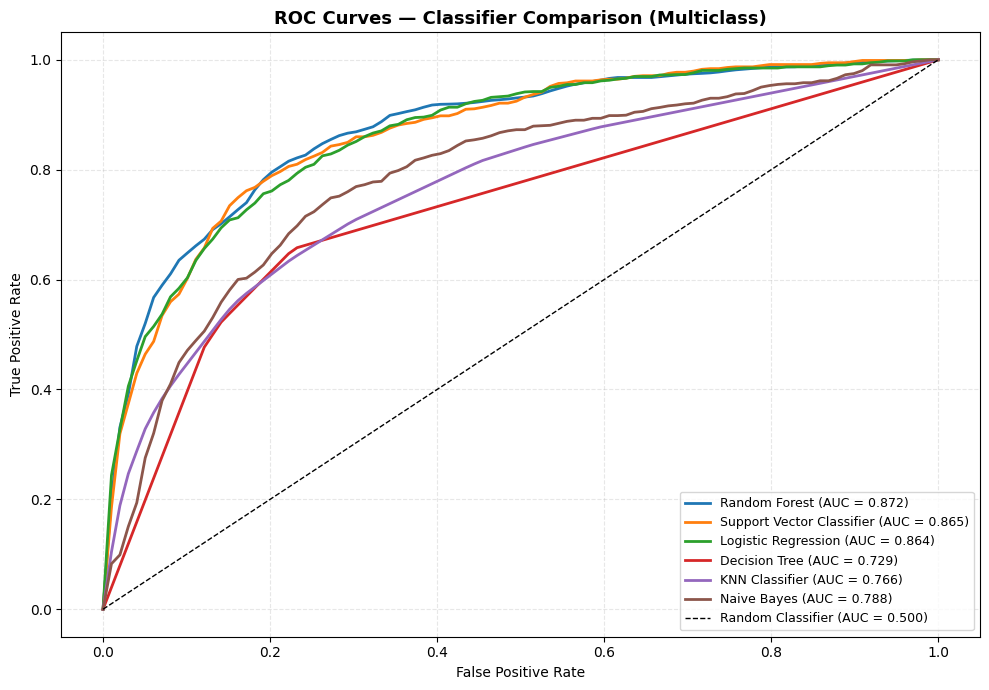

In [100]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 7))

# Loop over each model using the exact same structure as your code
for name in df_results["Model"]:
    proba = probabilities_dict[name]  # Array containing probabilities for all 3 classes
    
    # Initialize unified scale for averaging
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    
    # Loop over your 3 classes directly based on their positions
    for c in [0, 1, 2]:
        # Filter for the specific class on the fly without changing y_test
        fpr_c, tpr_c, _ = roc_curve((y_test == c).astype(int), proba[:, c])
        tprs.append(np.interp(mean_fpr, fpr_c, tpr_c))
        
    # Take the clean average of the True Positive Rates
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[0] = 0.0
    
    # Calculate macro AUC using sklearn's built-in multi_class support
    auc_score = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")
    
    plt.plot(mean_fpr, mean_tpr, lw=2, label=f"{name} (AUC = {auc_score:.3f})")

# Add the baseline diagonal for reference
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier (AUC = 0.500)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classifier Comparison (Multiclass)", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [102]:
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# =====================================================================
# 1. Target and Extract Your Exact Random Forest Pipeline
# =====================================================================
# This reconstructs the exact pipeline step used for your champion
champion_pipeline = Pipeline(steps=[
    ("standardizer", StandardScaler()), 
    ("model", models["Random Forest"])  # Targets the exact key from your dictionary
])

# Fit the pipeline to calculate the weights and importances
champion_pipeline.fit(X_train, y_train)

# Isolate the trained Random Forest classifier from the pipeline
champion_rf = champion_pipeline.named_steps["model"]

# =====================================================================
# 2. Extract and Sort Feature Importances
# =====================================================================
importances = champion_rf.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# =====================================================================
# 3. Filter Datasets to the Top 10 Features
# =====================================================================
top_features = feature_imp_df['Feature'].head(10).tolist()
print("=== Selected Top 10 Features ===")
for rank, feat in enumerate(top_features, 1):
    print(f"{rank}. {feat}")

X_train_reduced = X_train[top_features]
X_test_reduced = X_test[top_features]

# =====================================================================
# 4. Clone Champion Configuration & Retrain on Reduced Space
# =====================================================================
# clone() keeps your balanced class weights and estimator setups completely intact
rf_reduced = clone(champion_rf)
rf_reduced.random_state = 42

# Train directly on the lean, 10-feature subset
rf_reduced.fit(X_train_reduced, y_train)

# =====================================================================
# 5. Evaluate the Lean Model to Answer Question 3
# =====================================================================
y_pred_reduced = rf_reduced.predict(X_test_reduced)

print("\n=== Lean Random Forest Performance (Top 10 Features) ===")
print(classification_report(y_test, y_pred_reduced, target_names=['Dropout', 'Graduate', 'Enrolled']))

=== Selected Top 10 Features ===
1. Curricular units 2nd sem (approved)
2. Curricular units 2nd sem (grade)
3. Curricular units 1st sem (approved)
4. Curricular units 1st sem (grade)
5. Curricular units 2nd sem (evaluations)
6. Admission grade
7. Previous qualification (grade)
8. Age at enrollment
9. Curricular units 1st sem (evaluations)
10. Tuition fees up to date

=== Lean Random Forest Performance (Top 10 Features) ===
              precision    recall  f1-score   support

     Dropout       0.82      0.68      0.74       284
    Graduate       0.82      0.86      0.84       442
    Enrolled       0.42      0.50      0.46       159

    accuracy                           0.74       885
   macro avg       0.69      0.68      0.68       885
weighted avg       0.75      0.74      0.74       885



In [103]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Calculate single scalar scores for the reduced model
acc_red = accuracy_score(y_test, y_pred_reduced)
prec_red = precision_score(y_test, y_pred_reduced, average='macro', zero_division=0)
rec_red = recall_score(y_test, y_pred_reduced, average='macro', zero_division=0)
f1_red = f1_score(y_test, y_pred_reduced, average='macro', zero_division=0)

# 2. Organize the scalars into a clean summary DataFrame
df_reduced_summary = pd.DataFrame([{
    "Model": "Random Forest (Top 10 Features)",
    "Accuracy": acc_red,
    "Precision": prec_red,
    "Recall": rec_red,
    "F1-Score": f1_red
}])

# Display the final single-row table
df_reduced_summary

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest (Top 10 Features),0.736723,0.688458,0.680482,0.681187


In [ ]:

from sklearn.model_selection import GridSearchCV

# 1. Re-initialize your base pipeline structure
tuning_pipeline = Pipeline(steps=[
    ("standardizer", StandardScaler()),
    ("model", RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# 2. Define the parameter grid (Note the "model__" prefix to target the pipeline step)
param_grid = {
    'model__n_estimators': [25, 50, 75, 100],
    'model__max_features': ['sqrt', 'log2', None],
    'model__max_depth': [3, 6, 9]
}

# 3. Set up the Grid Search with 5-fold Cross-Validation
# Using refit="f1_macro" ensures the final model optimizes for the multiclass balance
rf_grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# 4. Run the grid search over your full training space
print("Optimizing Random Forest parameters via 5-Fold CV...")
rf_grid_search.fit(X_train, y_train)

# 5. Output the winning configurations
print("\n=== Optimal Tuning Results ===")
print("Best Hyperparameters:", rf_grid_search.best_params_)
print(f"Best Cross-Validation Macro F1-Score: {rf_grid_search.best_score_:.4f}")

Optimizing Random Forest parameters via 5-Fold CV...

=== Optimal Tuning Results ===
Best Hyperparameters: {'model__max_depth': 9, 'model__max_features': 'sqrt', 'model__n_estimators': 100}
Best Cross-Validation Macro F1-Score: 0.7126


In [ ]:

# Extract the absolute best estimator configuration
best_tuned_rf = rf_grid_search.best_estimator_
y_tuned_pred = best_tuned_rf.predict(X_test)

# Calculate the single-value metrics
tuned_acc = accuracy_score(y_test, y_tuned_pred)
tuned_prec = precision_score(y_test, y_tuned_pred, average='macro', zero_division=0)
tuned_rec = recall_score(y_test, y_tuned_pred, average='macro', zero_division=0)
tuned_f1 = f1_score(y_test, y_tuned_pred, average='macro', zero_division=0)

# Display in your clean table format
df_tuned_summary = pd.DataFrame([{
    "Model": "Tuned Random Forest (GridSearchCV)",
    "Accuracy": tuned_acc,
    "Precision": tuned_prec,
    "Recall": tuned_rec,
    "F1-Score": tuned_f1
}])

df_tuned_summary

,Model,Accuracy,Precision,Recall,F1-Score
0,Tuned Random Forest (GridSearchCV),0.737853,0.703262,0.695413,0.690162
